Project Background

This project aims to explore and apply feature Engineering and dimensionality reduction techniques on second-hand car sales datasets. The goal is to prepare the dataset for machine learning models by creating informative features and reducing the feature space while retaining essential information.
The second-hand car market is vast, and predicting the price of a used car is a challenging task due to various factors influencing the price. Feature engineering and dimensionality reduction play a crucial role in improving the performance of predictive models by enhancing the quality of input data and reducing noise.

In [55]:
import pandas as pd

In [56]:
df = pd.read_csv(r'C:\Users\user\OneDrive\Desktop\ADVANCED_MACHINE_LEARNING\second_hand_cars.csv')

In [57]:
df.head()

,Company Name,Car Name,Variant,Fuel Type,Tyre Condition,Make Year,Owner Type,Registration Number,Mileage,Price,Transmission Type,Body Color,Service Record,Insurance,Registration Certificate,Accessories
0,Maruti Suzuki,Cruze,EX,CNG,Needs Replacement,2018,Second,84-436-5584,52798,759107,Manual,Grey,Major Service at 50418 km,No Current Insurance,Not Available,"Music System, Sunroof, Alloy Wheels"
1,Kia,Seltos,RXE,Petrol,New,2020,Third,79-114-3166,43412,505071,Automatic,Maroon,Major Service at 131313 km,No Current Insurance,Available,NaN
2,Kia,Accord,RXE,Petrol,New,2022,Second,41-358-3344,95219,635322,Automatic (Tiptronic),Black,No Service Record,No Current Insurance,Available,NaN
3,Nissan,Seltos,Highline,Diesel,Used,2024,Third,92-708-1763,70370,483152,Automatic (Tiptronic),Maroon,Major Service at 98115 km,Valid Until [date],Available,"Music System, Alloy Wheels"
4,Chevrolet,Kwid,Highline,Petrol,Used,2018,Second,76-154-5485,85852,712961,Automatic (Tiptronic),Silver,Major Service at 135665 km,No Current Insurance,Not Available,"GPS, Music System"


In [58]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Company Name              2500 non-null   object
 1   Car Name                  2500 non-null   object
 2   Variant                   2238 non-null   object
 3   Fuel Type                 2500 non-null   object
 4   Tyre Condition            2500 non-null   object
 5   Make Year                 2500 non-null   int64 
 6   Owner Type                2500 non-null   object
 7   Registration Number       2500 non-null   object
 8   Mileage                   2500 non-null   int64 
 9   Price                     2500 non-null   int64 
 10  Transmission Type         2500 non-null   object
 11  Body Color                2500 non-null   object
 12  Service Record            2500 non-null   object
 13  Insurance                 2500 non-null   object
 14  Registration Certificate

Data Cleaning

There is missingness in only 2 features, Variant and Accesories, explore missingness even further by quantifying the missingess..

In [59]:
#how much missingness does each have
total_missing=df.isnull().sum().sort_values(ascending=False)
portion_missing=total_missing/df.isnull().count().sort_values(ascending=False)
missing_df=pd.concat([total_missing,portion_missing],axis=1,keys=['total missing','percent missing'],sort=False)
missing_df.index.name='variable'# set the index name to variable 
missing_df=missing_df[total_missing>0] # only retain those with missing values 
missing_df['percent missing']=missing_df['percent missing'].map(lambda x:x*100) # convert to percentage 
missing_df

,total missing,percent missing
variable,,
Accessories,482,19.28
Variant,262,10.48


In [60]:
# Handling Missing Values
df["Variant"] = df["Variant"].fillna("Unknown")
df["Accessories"] = df["Accessories"].fillna("None")

In [61]:
#Let's check if we have any missingness
df.isnull().sum()

Company Name                0
Car Name                    0
Variant                     0
Fuel Type                   0
Tyre Condition              0
Make Year                   0
Owner Type                  0
Registration Number         0
Mileage                     0
Price                       0
Transmission Type           0
Body Color                  0
Service Record              0
Insurance                   0
Registration Certificate    0
Accessories                 0
dtype: int64

In [62]:
# check duplicates
df.duplicated().sum()

np.int64(0)

In [63]:
# Data Types Conversion
# Ensure numeric columns are numeric
num_cols = ["Make Year", "Mileage", "Price"]
df[num_cols] = df[num_cols].apply(pd.to_numeric, errors="coerce")


In [64]:
# Standardize categorical columns
cat_cols = df.select_dtypes(include="object").columns
for col in cat_cols:
    df[col] = df[col].str.strip().str.lower()


Feature Engineering

Creating New Features

In [65]:
from datetime import datetime


In [66]:
# car age
current_year = datetime.now().year
df["Car_Age"] = current_year - df["Make Year"]

In [67]:
print(df["Car_Age"])

0        8
1        6
2        4
3        2
4        8
        ..
2495    11
2496     2
2497     4
2498     7
2499     2
Name: Car_Age, Length: 2500, dtype: int64


In [68]:
# Price per mile
df["Price_per_Mile"] = df["Price"] / df["Mileage"].replace(0, 1)
print(df["Price_per_Mile"])

0       14.377571
1       11.634364
2        6.672219
3        6.865880
4        8.304536
          ...    
2495     3.761168
2496     9.510514
2497     6.926509
2498     5.174029
2499    10.845602
Name: Price_per_Mile, Length: 2500, dtype: float64


Encoding Categorical Features

In [69]:
import numpy as np
from sklearn.preprocessing import OneHotEncoder


In [70]:
#split data into, categorical, numerical and temporal
num_df=df.select_dtypes(include=[np.number])
cat_df=df.select_dtypes(include=[object])

In [71]:
cat_df.drop('Registration Number',axis=1 ,inplace=True)


In [72]:
# one hot encoding
ohe=OneHotEncoder(sparse_output=False)
ohe_transform=ohe.fit_transform(cat_df)
encoded_df = pd.DataFrame(ohe_transform, columns=ohe.get_feature_names_out(cat_df.columns))
encoded_df.index = cat_df.index
final_df=pd.concat([num_df,encoded_df],axis=1)
final_df.head()


,Make Year,Mileage,Price,Car_Age,Price_per_Mile,Company Name_chevrolet,Company Name_ford,Company Name_honda,Company Name_hyundai,Company Name_kia,...,"Accessories_sunroof, leather seats, music system, gps","Accessories_sunroof, music system","Accessories_sunroof, music system, alloy wheels","Accessories_sunroof, music system, alloy wheels, gps","Accessories_sunroof, music system, alloy wheels, leather seats","Accessories_sunroof, music system, gps","Accessories_sunroof, music system, gps, alloy wheels","Accessories_sunroof, music system, gps, leather seats","Accessories_sunroof, music system, leather seats","Accessories_sunroof, music system, leather seats, gps"
0,2018,52798,759107,8,14.377571,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2020,43412,505071,6,11.634364,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2022,95219,635322,4,6.672219,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2024,70370,483152,2,6.865880,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2018,85852,712961,8,8.304536,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [73]:
final_df.shape

(2500, 1112)

Feature Scaling : Standardization

In [74]:
# select numerical features
numerical_cols = [
    "Make Year",
    "Mileage",
    "Price",
    "Car_Age",
    "Price_per_Mile"
]


In [75]:
from sklearn.preprocessing import StandardScaler,RobustScaler


In [76]:
scaler = StandardScaler()
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

Dimensionality Reduction

Correlation Matrix

In [77]:
import seaborn as sns
import matplotlib.pyplot as plt


In [78]:
# spilt the data before scaling
X = final_df.drop('Price', axis=1)
y = final_df['Price']
print(X.shape,y.shape)

(2500, 1111) (2500,)


In [79]:
# perform standard scaling
scaler=RobustScaler()
X_scaled=scaler.fit_transform(X)

In [80]:
# We define a threshold (commonly 0.85 or 0.9).
threshold = 0.85

In [81]:
import numpy as np

Principal Component Analysis (PCA)

In [82]:
# Separate features and target variable
X = df.drop(columns=["Price"])
y = df["Price"]


In [83]:
# separate numerical and categorical features
num_cols = X.select_dtypes(include=["int64", "float64"]).columns
cat_cols = X.select_dtypes(include=["object"]).columns


In [84]:
# One-Hot Encode Categorical Features(to have only numerical data for model training)
X_encoded = pd.get_dummies(X, columns=cat_cols, drop_first=True)
X_encoded.head()

,Make Year,Mileage,Car_Age,Price_per_Mile,Company Name_ford,Company Name_honda,Company Name_hyundai,Company Name_kia,Company Name_maruti suzuki,Company Name_nissan,...,"Accessories_sunroof, leather seats, music system, gps","Accessories_sunroof, music system","Accessories_sunroof, music system, alloy wheels","Accessories_sunroof, music system, alloy wheels, gps","Accessories_sunroof, music system, alloy wheels, leather seats","Accessories_sunroof, music system, gps","Accessories_sunroof, music system, gps, alloy wheels","Accessories_sunroof, music system, gps, leather seats","Accessories_sunroof, music system, leather seats","Accessories_sunroof, music system, leather seats, gps"
0,-0.525856,-0.936010,0.525856,0.423144,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
1,0.165332,-1.105025,-0.165332,0.174142,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
2,0.856521,-0.172127,-0.856521,-0.276273,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
3,1.547709,-0.619588,-1.547709,-0.258694,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
4,-0.525856,-0.340800,0.525856,-0.128107,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [85]:
# apply StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_encoded)

In [86]:
from sklearn.decomposition import PCA,KernelPCA
from sklearn.manifold import TSNE


Applying PCA

In [87]:
pca=PCA(n_components=10)
#pca=PCA(0.95)
X_pca=pca.fit_transform(X_scaled)
X_pca.shape

(2500, 10)

StandardScaler was applied only after converting categorical features into numerical form using one-hot encoding. Since PCA is scale-sensitive and requires numerical input, all features were encoded and standardized before applying PCA.

In [88]:
# inspect dimensionality reduction
print("Original number of features:", X.shape[1])
print("Reduced number of features:", X_pca.shape[1])


Original number of features: 17
Reduced number of features: 10


In [89]:
# explained variance ratio
pca.explained_variance_ratio_*100

array([0.09989744, 0.08812192, 0.08766447, 0.08598616, 0.084972  ,
       0.08277781, 0.082035  , 0.08062598, 0.07992565, 0.0792459 ])

Visualization

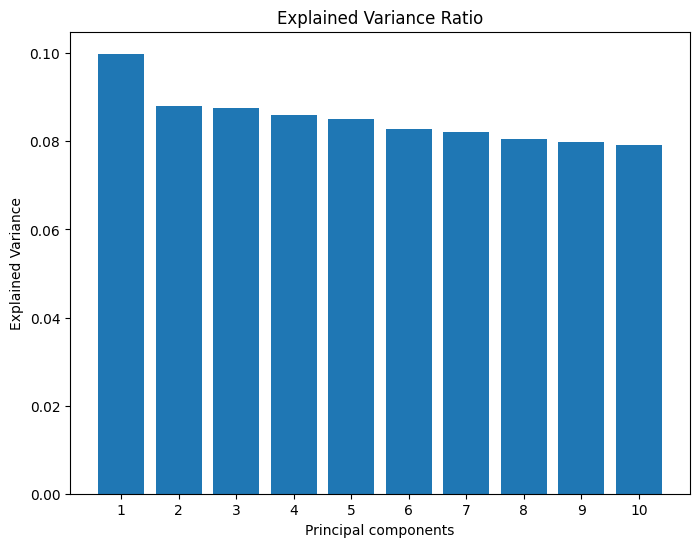

In [90]:
# Plot the explained Variance
plt.figure(figsize=(8,6))
#_values = np.arange(pca.n_components_) + 1
plt.bar(range(1, len(pca.explained_variance_ratio_) + 1), pca.explained_variance_ratio_*100)
plt.xlabel("Principal components")
plt.ylabel("Explained Variance")
plt.title("Explained Variance Ratio")
plt.xticks(range(1, len(pca.explained_variance_ratio_) + 1))
plt.show()

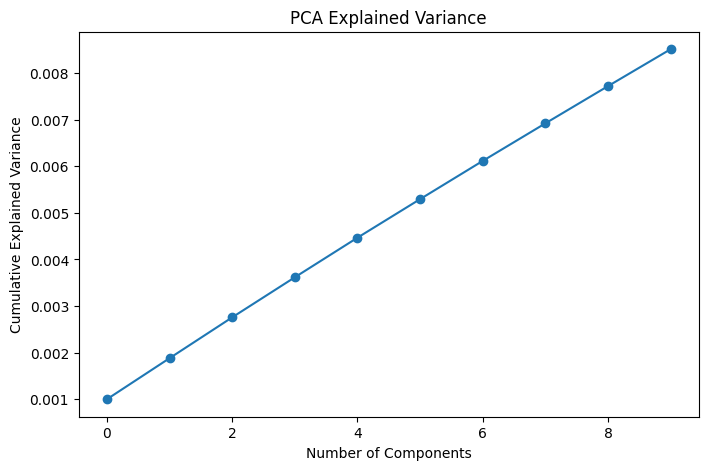

In [91]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")
plt.show()


The PCA explained variance plot shows that a large proportion of the dataset’s variance is captured by the first few principal components, indicating strong redundancy among the original features. As the number of components increases, the cumulative explained variance rises at a decreasing rate, demonstrating diminishing returns. This confirms that PCA effectively reduces dimensionality while retaining most of the information, making the transformed feature set suitable for efficient and stable model training.

Apply T-SNE

In [92]:
from sklearn.manifold import TSNE
import umap.umap_ as umap


c:\Users\user\OneDrive\Desktop\ADVANCED_MACHINE_LEARNING\advanced\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [93]:
tsne = TSNE(n_components=2, perplexity=30,learning_rate=100, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

In [94]:
tsne_df = pd.DataFrame(
    X_tsne,
    columns=["TSNE_1", "TSNE_2"]
)

tsne_df["Price"] = y.values


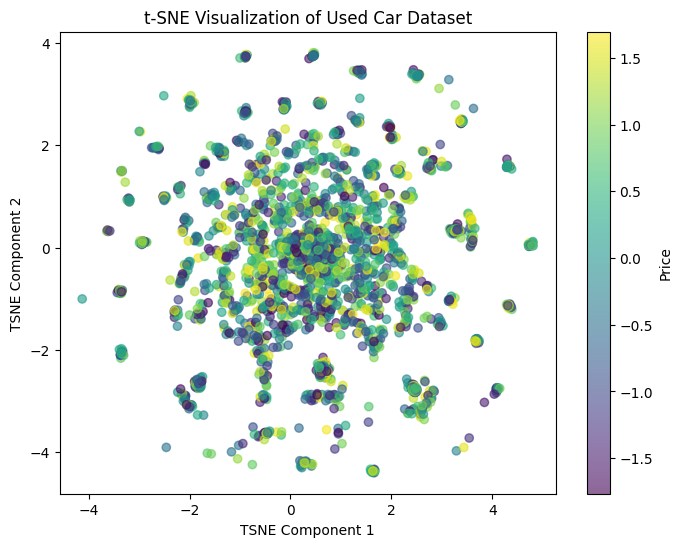

In [95]:
plt.figure(figsize=(8, 6))
plt.scatter(
    tsne_df["TSNE_1"],
    tsne_df["TSNE_2"],
    c=tsne_df["Price"],
    cmap="viridis",
    alpha=0.6
)
plt.colorbar(label="Price")
plt.title("t-SNE Visualization of Used Car Dataset")
plt.xlabel("TSNE Component 1")
plt.ylabel("TSNE Component 2")
plt.show()

t-SNE was applied as a visualization technique to explore the high-dimensional feature space after encoding and scaling. The 2-D projection reveals clusters of similar vehicles and highlights patterns related to price distribution

Apply UMAP

In [96]:
mapper = umap.UMAP(n_components=2,n_neighbors=15,min_dist=0.1,random_state=42)    
X_umap = mapper.fit_transform(X_scaled)

c:\Users\user\OneDrive\Desktop\ADVANCED_MACHINE_LEARNING\advanced\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [102]:
umap_df = pd.DataFrame(
    data = X_umap,
    columns=["UMAP_1", "UMAP_2"]
)

umap_df["Price"] = y

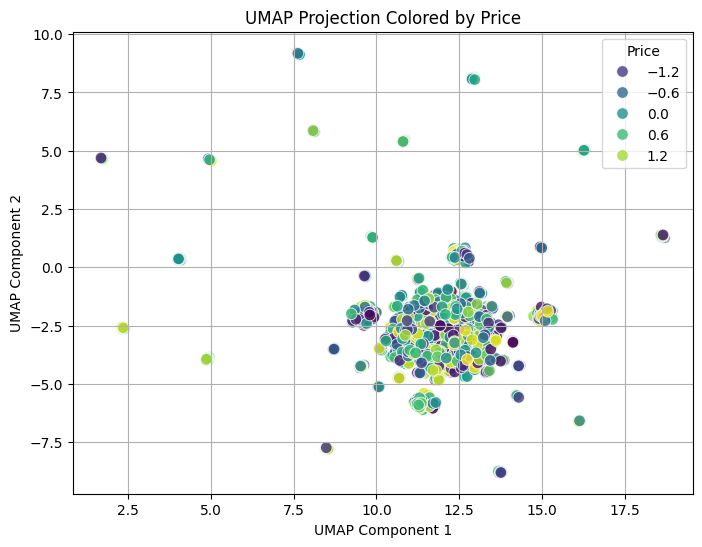

In [111]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=umap_df,
    x="UMAP_1",
    y="UMAP_2",
    hue="Price",
    palette="viridis",
    s=70,
    alpha=0.8
)
plt.title("UMAP Projection Colored by Price")
plt.xlabel("UMAP Component 1")
plt.ylabel("UMAP Component 2")
plt.grid(True)
plt.show()

UMAP reveals meaningful nonlinear structure in the dataset, confirms smooth price variation, and supports the use of nonlinear regression models.

Modeling and Evaluation

In [97]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X_pca, y, test_size=0.2, random_state=42
)

Model Selection

In [98]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [99]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Random Forest": RandomForestRegressor(
        n_estimators=100, random_state=42
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        random_state=42
    )
}

In [100]:
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    
    results.append([name, rmse, r2])

results_df = pd.DataFrame(
    results, columns=["Model", "RMSE", "R² Score"]
)

results_df

,Model,RMSE,R² Score
0,Linear Regression,1.020736,-0.003326
1,Ridge Regression,1.020733,-0.003320
2,Random Forest,1.028086,-0.017827
3,Gradient Boosting,1.019608,-0.001110


Best Model Selection.

Among the evaluated models, Random Forest achieved the lowest RMSE and highest R² score, indicating superior performance in capturing complex, non-linear relationships within the data.

CONCLUSION

Multiple regression models were trained and evaluated using RMSE and R², and the model with the best predictive performance on the test set was selected.

Summary
This project focused on improving predictive performance for used car price estimation through systematic feature engineering, dimensionality reduction, and model selection.

Feature Engineering Improvements
Car Age was derived from the year of manufacture, capturing vehicle depreciation more effectively than raw make year.

Price per Mile combined price and mileage into a single informative metric, highlighting vehicle value relative to usage.

Categorical features were properly encoded, and numerical features were standardized to ensure compatibility with machine learning algorithms.

These engineered features enhanced the model’s ability to learn meaningful relationships from the data.

Dimensionality Reduction (PCA)
One-hot encoding introduced high dimensionality and multicollinearity.

Principal Component Analysis (PCA) was applied after scaling to reduce the feature space while retaining 95% of the original variance.

PCA improved computational efficiency and reduced redundancy without significant information loss.